# 04. Integrator complex modules and C7orf26 (report Fig. 8; cf. paper Fig. 3B)

Pearson correlation between the expression profiles of perturbations targeting Integrator subunits and
C7orf26 (now INTS15), in K562 (genome-wide screen) and RPE1. Profiles use the genes selected for each screen
with `gwps.select_genes` (based on that screen's strong perturbations). The paper describes three modules:
INTS1-2-5-7-8 (with weaker links to INTS6 and INTS12), INTS3-4-9-11, and INTS10-13-14 together with C7orf26.

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import seaborn as sns
import gwps

integrator = [f"INTS{i}" for i in range(1, 15)] + ["C7orf26"]
modules = {"INTS1/2/5/7/8": ["INTS1", "INTS2", "INTS5", "INTS7", "INTS8"],
           "INTS3/4/9/11": ["INTS3", "INTS4", "INTS9", "INTS11"],
           "INTS10/13/14 + C7orf26": ["INTS10", "INTS13", "INTS14", "C7orf26"]}

def integrator_corr(name):
    a = gwps.load(name)
    o = a.obs
    strong = o.index[gwps.classify(o) == "strong"]
    genes = gwps.select_genes(a, strong)
    sel = o.index[o["target"].isin(integrator) & (o["num_cells_filtered"] >= 25)]
    prof = gwps.profiles(a[sel], genes)
    prof.index = o.loc[sel, "target"].values
    prof = prof.groupby(level=0).mean()   # average sgRNA pairs targeting the same gene
    return pd.DataFrame(np.corrcoef(prof.values), index=prof.index, columns=prof.index)

def module_summary(c):
    rows = {}
    for m, genes in modules.items():
        g = [x for x in genes if x in c.index]
        rest = [x for x in c.index if x not in g]
        rows[m] = {"within": gwps.corr_upper(c.loc[g, g]).mean(), "with other subunits": c.loc[g, rest].values.mean()}
    return pd.DataFrame(rows).T.round(2)

K562 genome-wide - missing: []


,within,with other subunits
INTS1/2/5/7/8,0.76,0.30
INTS3/4/9/11,0.60,0.22
INTS10/13/14 + C7orf26,0.74,0.10


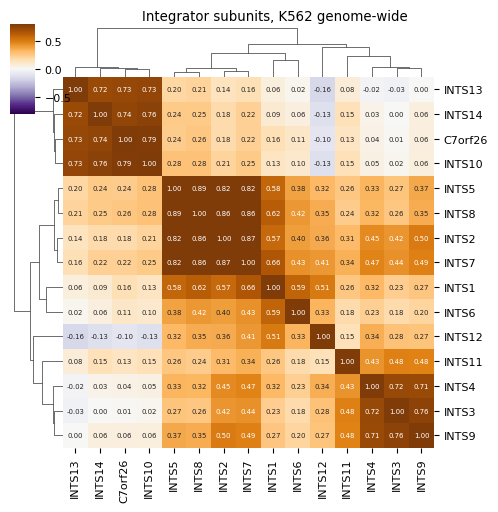

RPE1 - missing: ['INTS11', 'INTS7']


,within,with other subunits
INTS1/2/5/7/8,0.86,0.37
INTS3/4/9/11,0.87,0.31
INTS10/13/14 + C7orf26,0.76,0.11


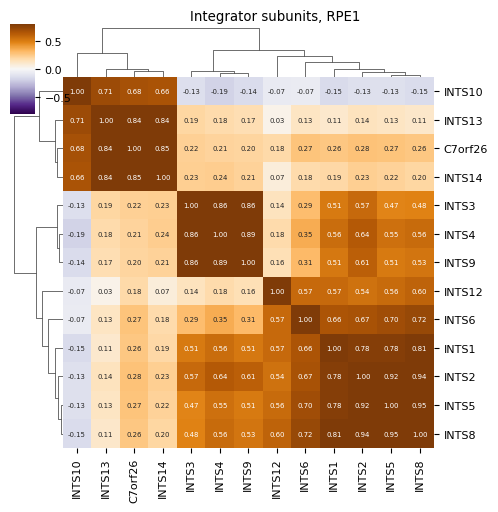

In [2]:
for name, label, fig_name in [("k562_gw", "K562 genome-wide", "fig08a_integrator_k562"), ("rpe1", "RPE1", "fig08b_integrator_rpe1")]:
    c = integrator_corr(name)
    print(label, "- missing:", sorted(set(integrator) - set(c.index)))
    display(module_summary(c))
    g = sns.clustermap(c, method="average", cmap=gwps.CORR_CMAP, vmin=-0.8, vmax=0.8, annot=True, fmt=".2f",
                       annot_kws={"size": 5}, figsize=(5, 5), dendrogram_ratio=0.12)
    g.ax_heatmap.set_xlabel(""); g.ax_heatmap.set_ylabel("")
    g.fig.suptitle(f"Integrator subunits, {label}", x=0.55, y=1.01)
    gwps.savefig(g.fig, fig_name)